# 3D PCA Visualization for DDoS Detection Dataset
This notebook performs Principal Component Analysis (PCA) in 3D space to visualize network traffic patterns.

## Section 1: Import Required Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

## Section 2: Load and Prepare Data

In [9]:
# Load the dataset
df_dropped = pd.read_csv('CIC_dfdropped/03-11/df_dropped_3000.csv')

# Display dataset information
print("Dataset shape:", df_dropped.shape)
print("\nLabel distribution:")
print(df_dropped['Label'].value_counts())
print("\nMissing values:")
print(df_dropped.isnull().sum().sum())

Dataset shape: (35588, 79)

Label distribution:
Label
BENIGN     17794
Syn         5527
UDP         3447
Portmap     3000
MSSQL       2803
LDAP        2724
NetBIOS      284
UDPLag         9
Name: count, dtype: int64

Missing values:
0


## Section 3: Select Labels and Extract Features

In [10]:
# Select which labels to compare (modify as needed)
labels_to_compare = ['NetBIOS', 'UDP']

# Filter data for selected labels
df_filtered = df_dropped[df_dropped['Label'].isin(labels_to_compare)].copy()

print(f"Filtered dataset shape: {df_filtered.shape}")
print("\nLabel distribution in filtered data:")
print(df_filtered['Label'].value_counts())

# Extract features (exclude Label and task_id)
feature_cols = [col for col in df_filtered.columns if col not in ['Label', 'task_id']]
X = df_filtered[feature_cols].values
y = df_filtered['Label'].values

# Handle missing values
X = np.nan_to_num(X, nan=0.0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_cols)}")

Filtered dataset shape: (3731, 79)

Label distribution in filtered data:
Label
UDP        3447
NetBIOS     284
Name: count, dtype: int64

Feature matrix shape: (3731, 77)
Number of features: 77


## Section 4: Apply PCA to Reduce to 3 Dimensions

In [11]:
# Standardize the features (critical for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 3 principal components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Display PCA information
print("PCA Results:")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"\nIndividual variance explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  PC3: {pca.explained_variance_ratio_[2]:.4f} ({pca.explained_variance_ratio_[2]*100:.2f}%)")
print(f"\nCumulative variance explained: {np.sum(pca.explained_variance_ratio_):.4f} ({np.sum(pca.explained_variance_ratio_)*100:.2f}%)")
print(f"Transformed data shape: {X_pca.shape}")

PCA Results:
Explained variance ratio: [0.47717609 0.21654668 0.10780494]

Individual variance explained:
  PC1: 0.4772 (47.72%)
  PC2: 0.2165 (21.65%)
  PC3: 0.1078 (10.78%)

Cumulative variance explained: 0.8015 (80.15%)
Transformed data shape: (3731, 3)


## Section 5: Visualize 3D PCA Results with Matplotlib

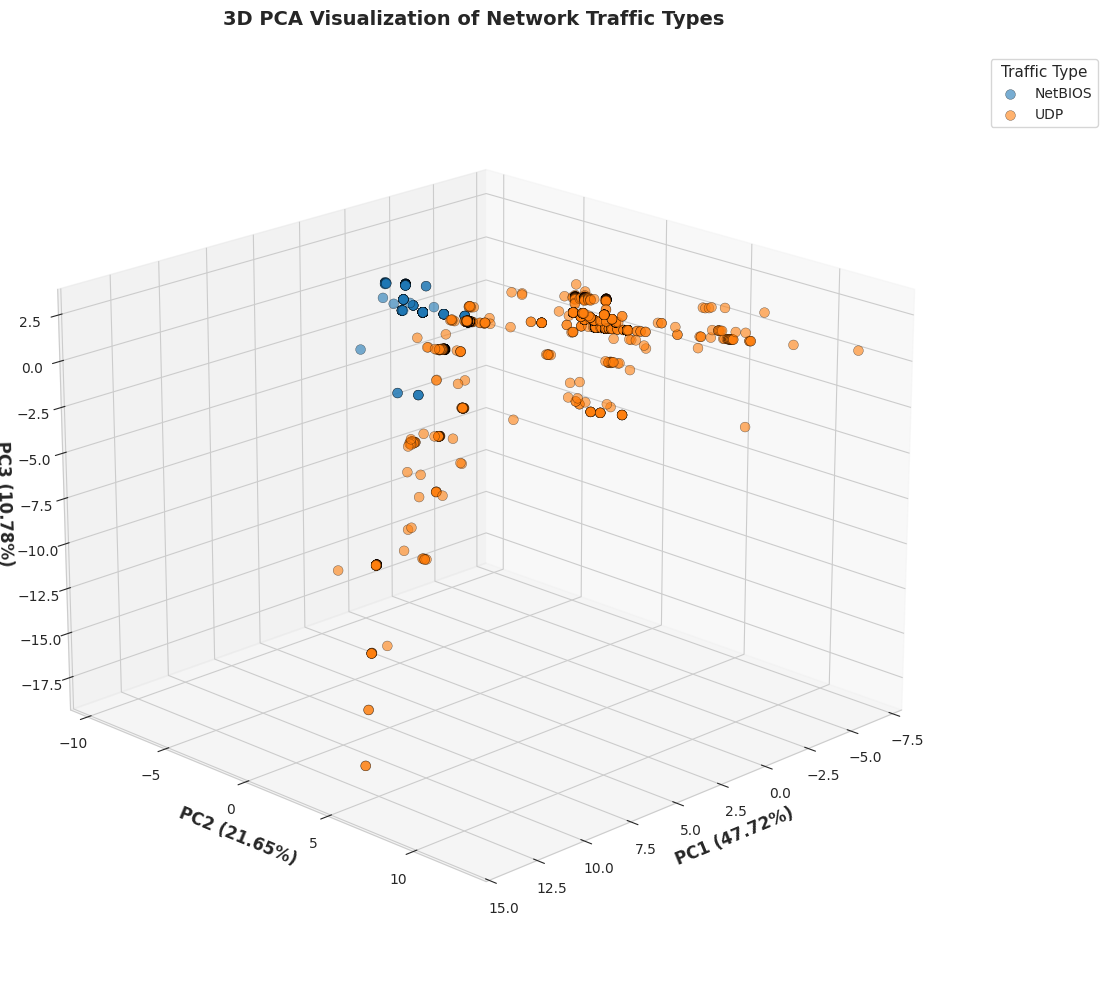

In [12]:
# Create a 3D scatter plot using Matplotlib
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
labels_unique = np.unique(y)


# Plot each label with a different color
for idx, label in enumerate(labels_unique):
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
               label=label, alpha=0.6, s=50, edgecolors='black', linewidth=0.3)

# Set labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)', fontsize=12, fontweight='bold')
ax.set_title('3D PCA Visualization of Network Traffic Types', fontsize=14, fontweight='bold', pad=20)

# Add legend
ax.legend(title='Traffic Type', fontsize=10, title_fontsize=11, loc='upper left', bbox_to_anchor=(1.05, 1))

# Adjust viewing angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## Section 6: Interactive 3D Visualization with Plotly

In [ ]:
# Create a dataframe for Plotly
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Label': y
})

# Create interactive 3D scatter plot
fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color='Label',
                     title='Interactive 3D PCA Visualization',
                     labels={
                         'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
                         'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
                         'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)'
                     },
                     hover_data=['Label'],
                     size_max=8)

fig.update_layout(width=1000, height=800, font=dict(size=11))
fig.show()

## Section 7: Analyze Principal Component Loadings

In [ ]:
# Create a dataframe of PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=feature_cols
)

# Display top contributing features for each PC
print("Top 10 Features Contributing to Each Principal Component:\n")

for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc} - Top 10 Contributing Features:")
    top_features = loadings[pc].abs().nlargest(10)
    print(top_features)

# Visualize loadings as heatmap
plt.figure(figsize=(10, 12))
top_n = 15
top_indices = loadings.iloc[:, 0].abs().nlargest(top_n).index.tolist()
sns.heatmap(loadings.loc[top_indices], annot=True, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading Value'}, fmt='.3f')
plt.title(f'Top {top_n} Features - PCA Loadings', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## Section 8: Explained Variance Analysis

In [ ]:
# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance explained
ax1.bar(range(1, 4), pca.explained_variance_ratio_, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variance Explained Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Variance Explained by Each PC', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, 4))
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(pca.explained_variance_ratio_):
    ax1.text(i+1, v+0.005, f'{v*100:.2f}%', ha='center', fontweight='bold')

# Cumulative variance explained
ax2.plot(range(1, 4), cumsum_var, marker='o', linewidth=2, markersize=10, color='steelblue')
ax2.fill_between(range(1, 4), cumsum_var, alpha=0.3, color='steelblue')
ax2.set_xlabel('Number of Principal Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
ax2.set_xticks(range(1, 4))
ax2.set_ylim([0, 1.05])
ax2.grid(alpha=0.3)
for i, v in enumerate(cumsum_var):
    ax2.text(i+1, v+0.02, f'{v*100:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by 3 PCs: {cumsum_var[-1]*100:.2f}%")

## Section 9: Statistical Summary by Label

In [ ]:
# Create summary statistics by label
df_summary = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Label': y
})

print("Statistical Summary by Traffic Type:\n")
summary_stats = df_summary.groupby('Label')[['PC1', 'PC2', 'PC3']].agg(['mean', 'std', 'min', 'max'])
print(summary_stats)